In [2]:
from google.colab import files

print('Por favor, selecciona los archivos para subir')
uploaded = files.upload()

Por favor, selecciona los archivos para subir


Saving ECB Data Portal.json to ECB Data Portal.json
Saving Plazo medio de las hipotecas constituidas.csv to Plazo medio de las hipotecas constituidas.csv
Saving Tipo de interés medio al inicio de las hipotecas constituidas.csv to Tipo de interés medio al inicio de las hipotecas constituidas.csv


In [85]:
import pandas as pd
import json

# Cargar los CSVs
df_plazo = pd.read_csv('Plazo medio de las hipotecas constituidas.csv', sep=None, engine='python')
df_interes = pd.read_csv('Tipo de interés medio al inicio de las hipotecas constituidas.csv', sep=None, engine='python')

# Cargar el JSON
with open('ECB Data Portal.json', 'r', encoding='utf-8') as f:
    datos_json = json.load(f)

# Limpiar nombres de columnas (Quitar el carácter invisible \ufeff y espacios)
df_plazo.columns = df_plazo.columns.str.replace('\ufeff', '').str.strip()
df_interes.columns = df_interes.columns.str.replace('\ufeff', '').str.strip()

print("Archivos cargados y columnas normalizadas.")
print(f"Columnas Plazo: {df_plazo.columns.tolist()}")
print(f"Columnas Interés: {df_interes.columns.tolist()}")

Archivos cargados y columnas normalizadas.
Columnas Plazo: ['Tipo de interés', 'Naturaleza de la finca', 'Periodo', 'Total']
Columnas Interés: ['Tipo de interés', 'Naturaleza de la finca', 'Periodo', 'Total']


In [86]:
# Ver los primeros 10 registros de cada uno para comparar
print("--- MUESTRA PLAZO MEDIO ---")
print(df_plazo.head(10))

print("\n--- MUESTRA INTERÉS MEDIO ---")
print(df_interes.head(10))

# Ver si hay valores únicos en la columna 'Total' del archivo de Interés
# (Para comprobar si realmente todo es '100' o hay más datos)
print("\nValores únicos en 'Total' (Archivo Interés):")
print(df_interes['Total'].unique())

--- MUESTRA PLAZO MEDIO ---
  Tipo de interés Naturaleza de la finca  Periodo Total
0           Total           Total fincas  2026M02  3,08
1           Total           Total fincas  2026M01  3,22
2           Total           Total fincas  2025M12  3,09
3           Total           Total fincas  2025M11  3,16
4           Total           Total fincas  2025M10  3,17
5           Total           Total fincas  2025M09  3,16
6           Total           Total fincas  2025M08  3,18
7           Total           Total fincas  2025M07  3,16
8           Total           Total fincas  2025M06  3,23
9           Total           Total fincas  2025M05  3,11

--- MUESTRA INTERÉS MEDIO ---
  Tipo de interés Naturaleza de la finca  Periodo Total
0           Total           Total fincas  2026M02   100
1           Total           Total fincas  2026M01   100
2           Total           Total fincas  2025M12   100
3           Total           Total fincas  2025M11   100
4           Total           Total fincas  202

In [87]:
# Normalización profesional de nombres de columnas
def normalizar_nombres(df):
    df.columns = (df.columns
                  .str.replace('\ufeff', '')
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('á', 'a')
                  .str.replace('é', 'e')
                  .str.replace('í', 'i')
                  .str.replace('ó', 'o')
                  .str.replace('ú', 'u'))
    return df

# Aplicamos la normalización a los dos DataFrames
df_plazo = normalizar_nombres(df_plazo)
df_interes = normalizar_nombres(df_interes)

print("Nombres de columnas normalizados.")
print(f"Columnas Plazo actualizadas: {df_plazo.columns.tolist()}")
print(f"Columnas Interés actualizadas: {df_interes.columns.tolist()}")

Nombres de columnas normalizados.
Columnas Plazo actualizadas: ['tipo_de_interes', 'naturaleza_de_la_finca', 'periodo', 'total']
Columnas Interés actualizadas: ['tipo_de_interes', 'naturaleza_de_la_finca', 'periodo', 'total']


In [88]:
# Inspección de la estructura del JSON del BCE
print(f"El JSON contiene {len(datos_json)} registros.")

# Miramos el primer elemento para ver qué campos tiene
if len(datos_json) > 0:
    print("\nEstructura del primer registro del JSON:")
    # Usamos json.dumps para que se vea "bonito" y ordenado
    print(json.dumps(datos_json[0], indent=4))
else:
    print("Error")

El JSON contiene 278 registros.

Estructura del primer registro del JSON:
{
    "DATE": "2003-01-31",
    "TIME PERIOD": "2003Jan",
    "Cost of borrowing for households for house purchase  (MIR.M.ES.B.A2C.AM.R.A.2250.EUR.N)": 4.21
}


In [89]:
# Convertir la lista JSON en un DataFrame y normalizar
df_bce = pd.DataFrame(datos_json)

# Renombramos la columna larguísima a algo manejable
columna_larga = "Cost of borrowing for households for house purchase  (MIR.M.ES.B.A2C.AM.R.A.2250.EUR.N)"
df_bce = df_bce.rename(columns={
    "DATE": "fecha_bce",
    "TIME PERIOD": "periodo_bce",
    columna_larga: "interes_bce"
})

# Normalizamos los nombres de las columnas del BCE (minúsculas y sin espacios)
df_bce.columns = df_bce.columns.str.lower().str.replace(' ', '_')

print("Datos del BCE convertidos a DataFrame y normalizados.")
print(df_bce.head())

Datos del BCE convertidos a DataFrame y normalizados.
    fecha_bce periodo_bce  interes_bce
0  2003-01-31     2003Jan         4.21
1  2003-02-28     2003Feb         4.06
2  2003-03-31     2003Mar         3.90
3  2003-04-30     2003Apr         3.79
4  2003-05-31     2003May         3.72


In [90]:
# Estandarización de Fechas (Casting a datetime)

# Para los DataFrames del INE (formato 2026M02)
df_plazo['fecha_master'] = pd.to_datetime(df_plazo['periodo'], format='%YM%m', errors='coerce')
df_interes['fecha_master'] = pd.to_datetime(df_interes['periodo'], format='%YM%m', errors='coerce')

# Para el DataFrame del BCE (formato 2003-01-31)
df_bce['fecha_master'] = pd.to_datetime(df_bce['fecha_bce'], errors='coerce')

# Como el INE suele dar el dato a principio de mes y el BCE a final,
# normalizamos todo al día 1 del mes para que coincidan perfectamente.
df_bce['fecha_master'] = df_bce['fecha_master'].dt.to_period('M').dt.to_timestamp()
df_plazo['fecha_master'] = df_plazo['fecha_master'].dt.to_period('M').dt.to_timestamp()
df_interes['fecha_master'] = df_interes['fecha_master'].dt.to_period('M').dt.to_timestamp()

print("Fechas estandarizadas a 'fecha_master'.")
print(f"Muestra Fecha INE: {df_plazo['fecha_master'].iloc[0]}")
print(f"Muestra Fecha BCE: {df_bce['fecha_master'].iloc[0]}")

Fechas estandarizadas a 'fecha_master'.
Muestra Fecha INE: 2026-02-01 00:00:00
Muestra Fecha BCE: 2003-01-01 00:00:00


In [91]:
# Conversión de la columna 'total' de texto a número (float)

def limpiar_decimales(serie):
    return pd.to_numeric(serie.astype(str).str.replace(',', '.'), errors='coerce')

# Aplicamos la limpieza a los dos DataFrames del INE
df_plazo['total_num'] = limpiar_decimales(df_plazo['total'])
df_interes['total_num'] = limpiar_decimales(df_interes['total'])

# Verificamos los tipos de datos finales
print("Valores convertidos a números.")
print(df_plazo[['fecha_master', 'total', 'total_num']].head())

Valores convertidos a números.
  fecha_master total  total_num
0   2026-02-01  3,08       3.08
1   2026-01-01  3,22       3.22
2   2025-12-01  3,09       3.09
3   2025-11-01  3,16       3.16
4   2025-10-01  3,17       3.17


In [118]:
# Investigación forense del valor '100'
# Vamos a ver las filas completas donde aparece el 100, pero solo una muestra
investigacion_100 = df_interes[df_interes['total_num'] == 100.0].head(10)

print("--- ANÁLISIS DE FILAS CON VALOR 100 ---")
print(investigacion_100[['fecha_master', 'tipo_de_interes', 'naturaleza_de_la_finca', 'total']])

# También vamos a ver si hay algún 100 en fechas antiguas o solo en las nuevas
print("\n¿En qué años aparece el 100?")
print(df_interes[df_interes['total_num'] == 100.0]['fecha_master'].dt.year.unique())

--- ANÁLISIS DE FILAS CON VALOR 100 ---
  fecha_master tipo_de_interes naturaleza_de_la_finca total
0   2026-02-01           Total           Total fincas   100
1   2026-01-01           Total           Total fincas   100
2   2025-12-01           Total           Total fincas   100
3   2025-11-01           Total           Total fincas   100
4   2025-10-01           Total           Total fincas   100
5   2025-09-01           Total           Total fincas   100
6   2025-08-01           Total           Total fincas   100
7   2025-07-01           Total           Total fincas   100
8   2025-06-01           Total           Total fincas   100
9   2025-05-01           Total           Total fincas   100

¿En qué años aparece el 100?
[2026 2025 2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013
 2012 2011 2010 2009]


In [119]:
# Generar la variable que falta
# Creamos las variables dummy para que Python reconozca 'df_interes_encoded'
df_interes_encoded = pd.get_dummies(df_interes, columns=['naturaleza_de_la_finca', 'tipo_de_interes'], prefix=['finca', 'tipo'])

# Convertimos booleanos a enteros (1 y 0)
for col in df_interes_encoded.columns:
    if 'finca_' in col or 'tipo_' in col:
        df_interes_encoded[col] = df_interes_encoded[col].astype(int)

print("Variable 'df_interes_encoded' creada correctamente.")

Variable 'df_interes_encoded' creada correctamente.


In [120]:
# Análisis de solapamiento temporal
def obtener_rango(df, nombre):
    return f"{nombre}: desde {df['fecha_master'].min().date()} hasta {df['fecha_master'].max().date()}"

print("--- RANGOS DISPONIBLES ---")
print(obtener_rango(df_plazo, "INE Plazos"))
print(obtener_rango(df_interes, "INE Intereses"))
print(obtener_rango(df_bce, "BCE Datos"))

# Buscamos la fecha de inicio común (la más tardía de las tres)
fecha_inicio_comun = max(df_plazo['fecha_master'].min(),
                         df_interes['fecha_master'].min(),
                         df_bce['fecha_master'].min())

# Buscamos la fecha de fin común (la más temprana de las tres)
fecha_fin_comun = min(df_plazo['fecha_master'].max(),
                      df_interes['fecha_master'].max(),
                      df_bce['fecha_master'].max())

print(f"\nEl periodo de estudio real para el ML será:")
print(f"Del {fecha_inicio_comun.date()} al {fecha_fin_comun.date()}")

--- RANGOS DISPONIBLES ---
INE Plazos: desde 2009-01-01 hasta 2026-02-01
INE Intereses: desde 2009-01-01 hasta 2026-02-01
BCE Datos: desde 2003-01-01 hasta 2026-02-01

El periodo de estudio real para el ML será:
Del 2009-01-01 al 2026-02-01


In [121]:
# Creación del Dataset Maestro (Fusión Corregida)

# 1. Unimos los DataFrames del INE
# Nota: Quitamos 'total' de la unión para evitar conflictos de nombres, ya que cada tabla tiene su propio 'total' (plazo e interés)
df_ine = pd.merge(
    df_plazo,
    df_interes_encoded,
    on=['fecha_master', 'periodo'],
    suffixes=('_plazo', '_interes')
)

# 2. Unimos con los datos del BCE
df_final = pd.merge(
    df_ine,
    df_bce[['fecha_master', 'interes_bce']],
    on='fecha_master',
    how='inner'
)

# 3. Listamos las columnas que realmente existen para no dar error
# Buscamos todas las que tengan 'finca', 'tipo', el interés del BCE y los totales numéricos
cols_existentes = df_final.columns.tolist()
columnas_mantener = [c for c in cols_existentes if
                     'finca_' in c.lower() or
                     'tipo_' in c.lower() or
                     c in ['fecha_master', 'interes_bce', 'total_num_plazo', 'total_num_interes']]

df_final = df_final[columnas_mantener]

# 4. Verificación de integridad
print(f"Dataset Maestro creado con {df_final.shape[0]} filas.")
print(f"Columnas finales: {df_final.columns.tolist()}")
print("\nPrimeras filas del dataset unificado:")
print(df_final.head())

Dataset Maestro creado con 7416 filas.
Columnas finales: ['tipo_de_interes', 'fecha_master', 'total_num_plazo', 'total_num_interes', 'finca_Total fincas', 'finca_Viviendas', 'tipo_Fijo', 'tipo_Total', 'tipo_Variable', 'interes_bce']

Primeras filas del dataset unificado:
  tipo_de_interes fecha_master  total_num_plazo  total_num_interes  \
0           Total   2026-02-01             3.08              100.0   
1           Total   2026-02-01             3.08              100.0   
2           Total   2026-02-01             3.08               61.0   
3           Total   2026-02-01             3.08               64.8   
4           Total   2026-02-01             3.08               39.0   

   finca_Total fincas  finca_Viviendas  tipo_Fijo  tipo_Total  tipo_Variable  \
0                   1                0          0           1              0   
1                   0                1          0           1              0   
2                   1                0          1           0      

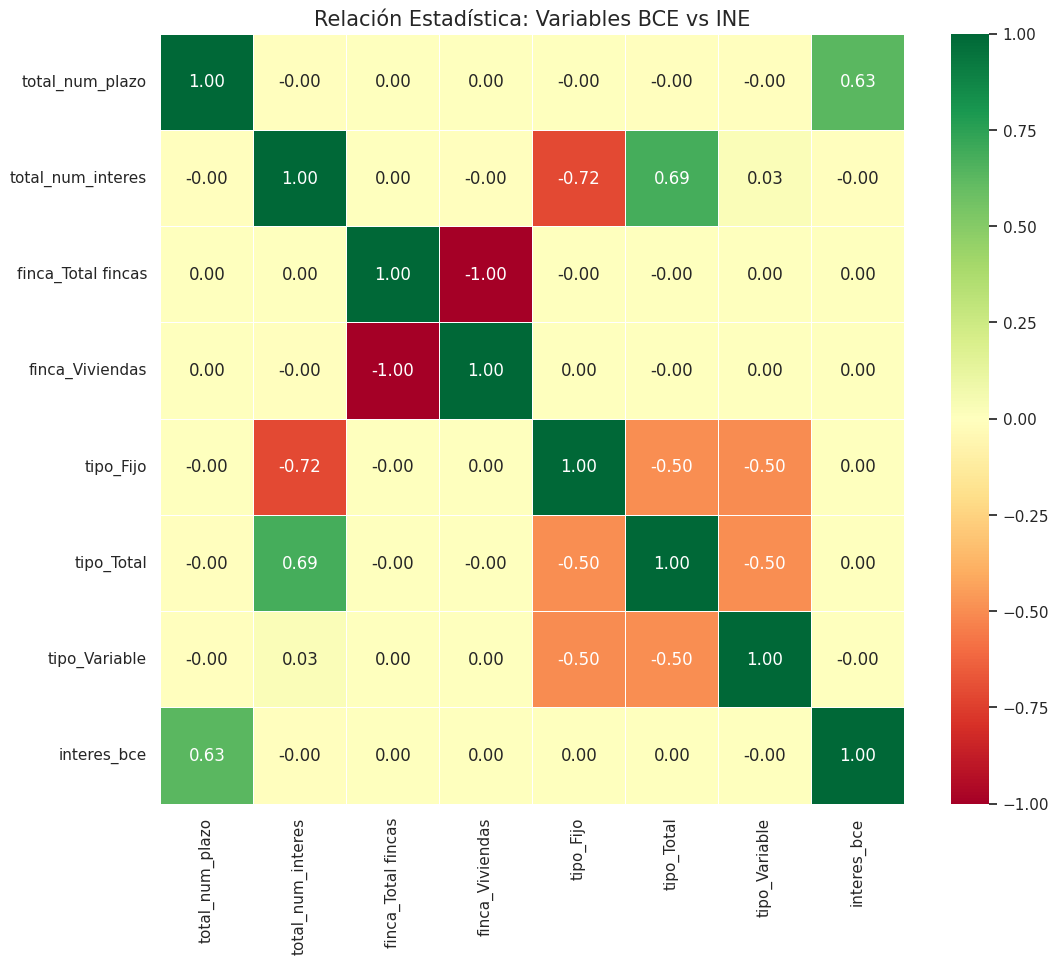

In [122]:
# Análisis de Correlación (Versión corregida)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Calculamos la correlación especificando que solo use números
plt.figure(figsize=(12, 10))
matriz_corr = df_final.corr(numeric_only=True)

sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title("Relación Estadística: Variables BCE vs INE", fontsize=15)
plt.show()

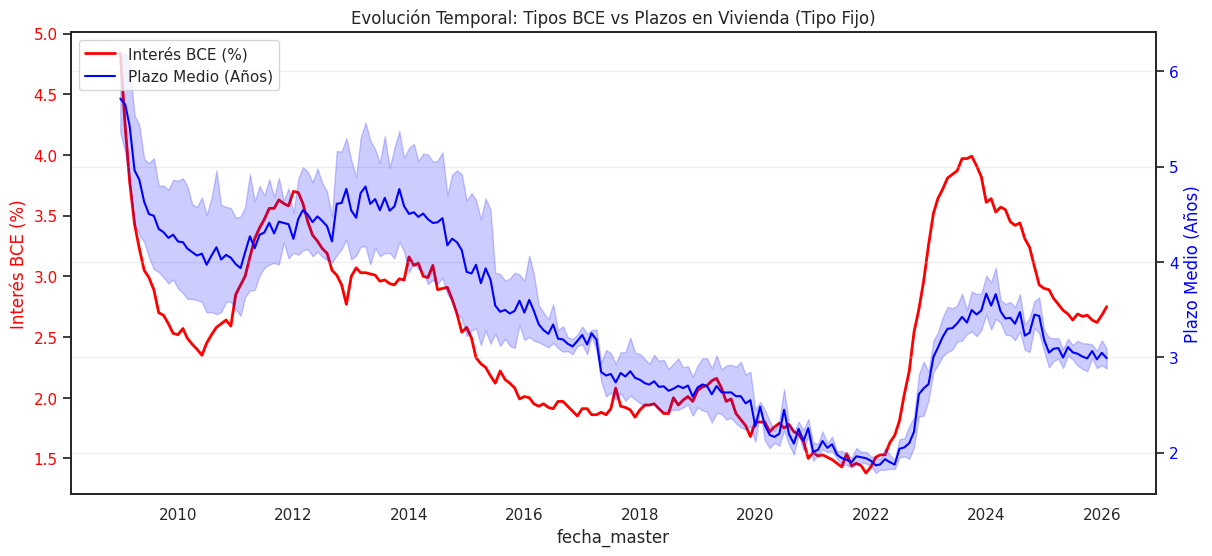

In [97]:
# 1. EVOLUCIÓN TEMPORAL CORREGIDA: BCE vs Plazos Hipotecarios
fig, ax1 = plt.subplots(figsize=(14, 6))

# Filtrado para el análisis (Viviendas y Fijo)
df_vivienda_fija = df_final[(df_final['finca_Viviendas'] == 1) & (df_final['tipo_Fijo'] == 1)]

# Eje Izquierdo: Interés BCE
line1 = sns.lineplot(data=df_vivienda_fija, x='fecha_master', y='interes_bce',
                     label='Interés BCE (%)', color='red', linewidth=2, ax=ax1)
ax1.set_ylabel('Interés BCE (%)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Eje Derecho: Plazo Medio
ax2 = ax1.twinx()
line2 = sns.lineplot(data=df_vivienda_fija, x='fecha_master', y='total_num_plazo',
                     label='Plazo Medio (Años)', color='blue', ax=ax2)
ax2.set_ylabel('Plazo Medio (Años)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# SOLUCIÓN A LOS LABELS MEZCLADOS:
# Combinamos las leyendas de ambos ejes en una sola
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Eliminamos la leyenda automática que queda suelta
ax1.get_legend().remove()

plt.title("Evolución Temporal: Tipos BCE vs Plazos en Vivienda (Tipo Fijo)")
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2071/2057126386.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='finca_Viviendas', y='total_num_plazo', palette='Set2')
/tmp/ipykernel_2071/2057126386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='finca_Viviendas', y='total_num_interes', palette='Set3')


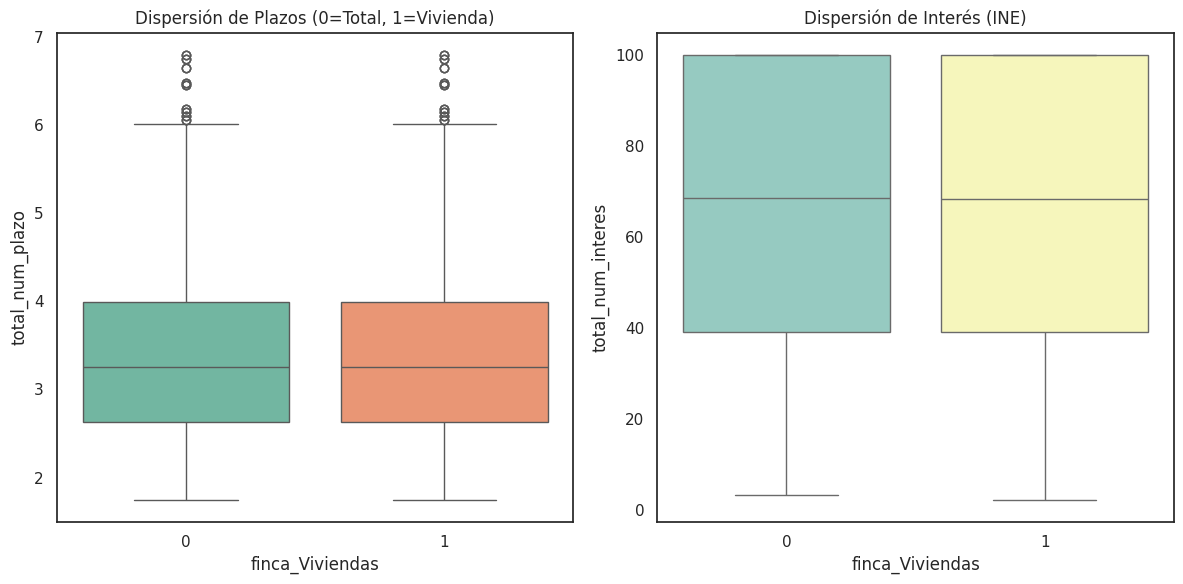

In [98]:
# 2. COMPARATIVA DE DISTRIBUCIÓN: Viviendas vs Total Fincas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_final, x='finca_Viviendas', y='total_num_plazo', palette='Set2')
plt.title("Dispersión de Plazos (0=Total, 1=Vivienda)")

plt.subplot(1, 2, 2)
sns.boxplot(data=df_final, x='finca_Viviendas', y='total_num_interes', palette='Set3')
plt.title("Dispersión de Interés (INE)")

plt.tight_layout()
plt.show()

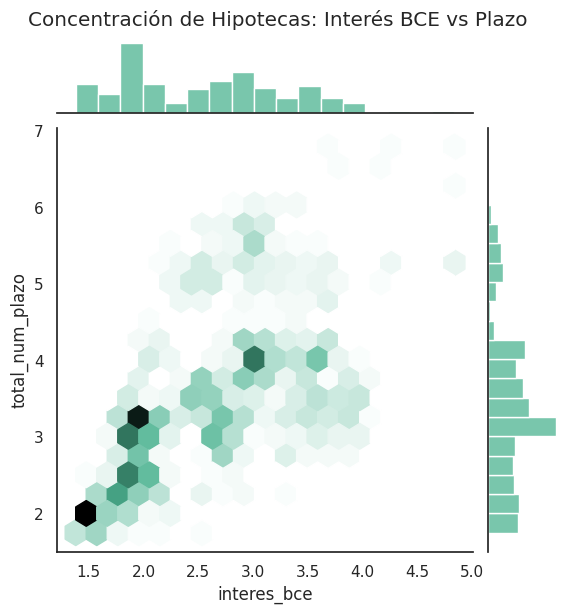

In [99]:
# 3. DENSIDAD Y DISPERSIÓN: BCE vs Plazo
sns.jointplot(data=df_vivienda_fija, x='interes_bce', y='total_num_plazo', kind="hex", color="#4CB391")
plt.suptitle("Concentración de Hipotecas: Interés BCE vs Plazo", y=1.02)
plt.show()

/tmp/ipykernel_2071/1454135763.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lags, y=correlaciones, palette='viridis')


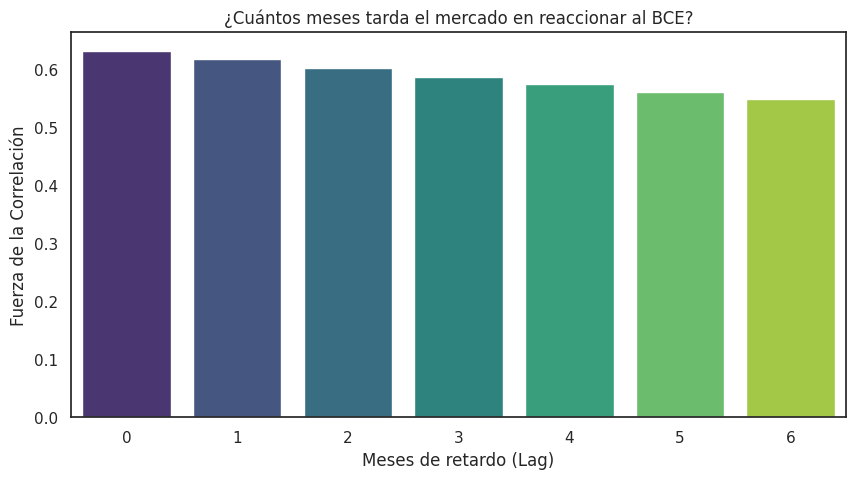

In [123]:
# 4: El "Delay" entre Europa y España
lags = [0, 1, 2, 3, 4, 5, 6]
correlaciones = []

# Filtramos solo viviendas para que el análisis sea puro
df_lag = df_final[df_final['finca_Viviendas'] == 1].copy()

for lag in lags:
    # Desplazamos el interés del BCE hacia adelante
    corr = df_lag['total_num_plazo'].corr(df_lag['interes_bce'].shift(lag))
    correlaciones.append(corr)

# Visualización del retraso
plt.figure(figsize=(10, 5))
sns.barplot(x=lags, y=correlaciones, palette='viridis')
plt.title("¿Cuántos meses tarda el mercado en reaccionar al BCE?")
plt.xlabel("Meses de retardo (Lag)")
plt.ylabel("Fuerza de la Correlación")
plt.show()

max_lag = lags[correlaciones.index(max(correlaciones))]

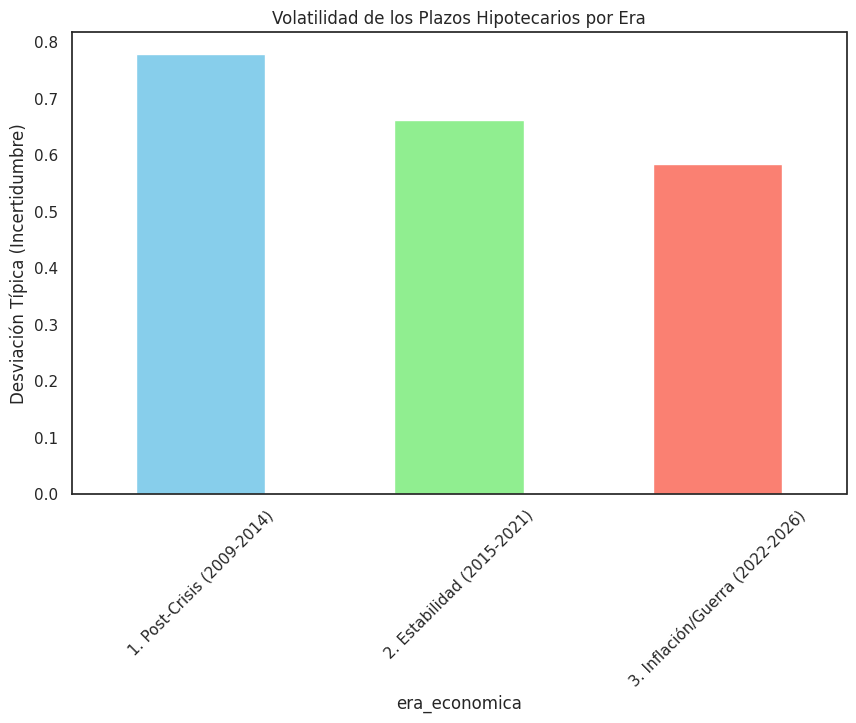

In [124]:
# 5: Volatilidad en las 3 Eras
def definir_era(fecha):
    if fecha.year < 2015: return '1. Post-Crisis (2009-2014)'
    elif fecha.year < 2022: return '2. Estabilidad (2015-2021)'
    else: return '3. Inflación/Guerra (2022-2026)'

df_final['era_economica'] = df_final['fecha_master'].apply(definir_era)

# Calculamos la desviación típica (volatilidad) de los plazos por era
volatilidad = df_final.groupby('era_economica')['total_num_plazo'].std()

plt.figure(figsize=(10, 6))
volatilidad.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Volatilidad de los Plazos Hipotecarios por Era")
plt.ylabel("Desviación Típica (Incertidumbre)")
plt.xticks(rotation=45)
plt.show()

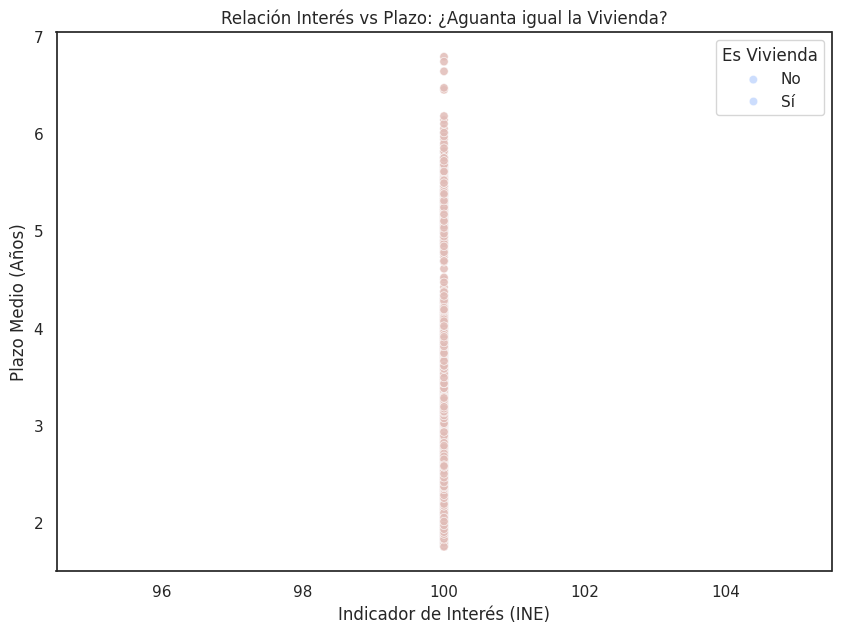

In [125]:
# 6.1: Sensibilidad Vivienda vs Otras Fincas
plt.figure(figsize=(10, 7))

# Solo comparamos el "Total" de cada una para no saturar de puntos
df_sensibilidad = df_final[df_final['tipo_Total'] == 1]

sns.scatterplot(data=df_sensibilidad, x='total_num_interes', y='total_num_plazo',
                hue='finca_Viviendas', alpha=0.6, palette='coolwarm')

plt.title("Relación Interés vs Plazo: ¿Aguanta igual la Vivienda?")
plt.xlabel("Indicador de Interés (INE)")
plt.ylabel("Plazo Medio (Años)")
plt.legend(title="Es Vivienda", labels=['No', 'Sí'])
plt.show()

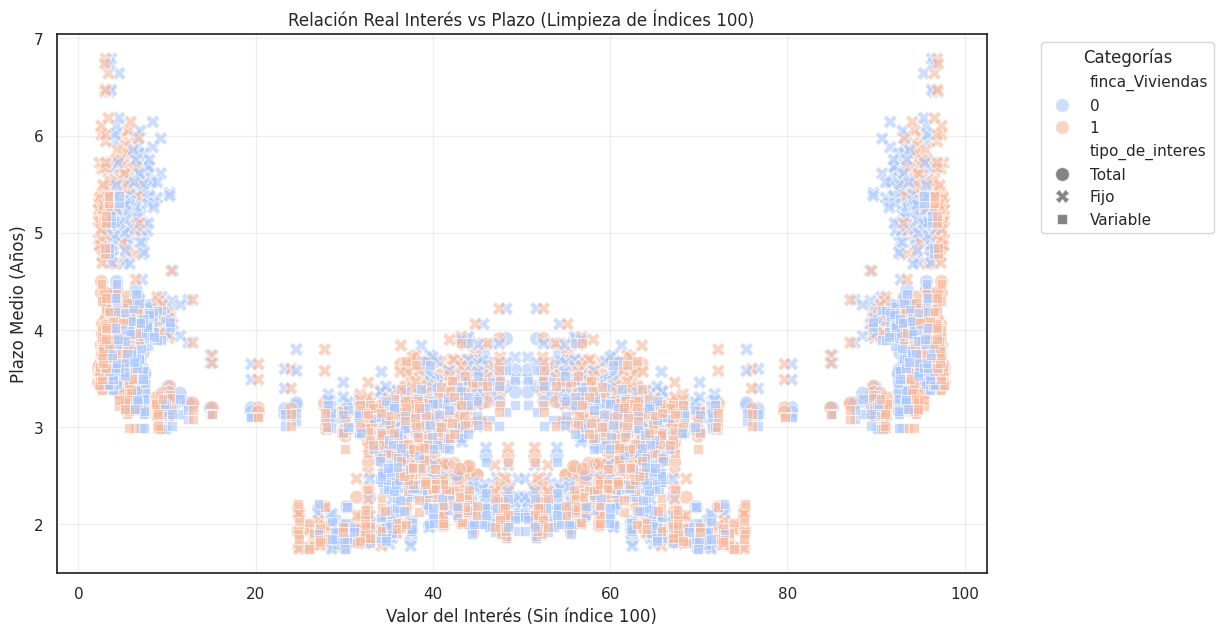

In [126]:
# 6.2: Análisis de Sensibilidad sin filtros excluyentes
plt.figure(figsize=(12, 7))

# 1. Filtramos SOLO los 100 para no perder datos por otras columnas
df_limpio = df_final[df_final['total_num_interes'] != 100.0].copy()

# Verificamos si hay datos antes de pintar
if len(df_limpio) > 0:
    # 2. Usamos un Scatter Plot con 'hue' para las viviendas y 'style' para el tipo de interes
    sns.scatterplot(data=df_limpio, x='total_num_interes', y='total_num_plazo',
                    hue='finca_Viviendas', style='tipo_de_interes',
                    alpha=0.6, palette='coolwarm', s=100)

    plt.title("Relación Real Interés vs Plazo (Limpieza de Índices 100)")
    plt.xlabel("Valor del Interés (Sin índice 100)")
    plt.ylabel("Plazo Medio (Años)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Categorías')
    plt.grid(True, alpha=0.3)
    plt.show()

# Entrenar modelos ML

In [127]:
# Transformación Numérica
import pandas as pd

# 1. Convertimos el texto ('Fijo', 'Variable') en columnas de 0 y 1
df_numeric = pd.get_dummies(df_final, columns=['tipo_de_interes'], prefix='tipo')

# 2. Borramos CUALQUIER columna que no sea un número (adiós a los errores de string)
df_clean = df_numeric.select_dtypes(include=['number'])

print("Datos convertidos a formato matemático.")
print(f"Columnas disponibles ahora: {df_clean.columns.tolist()}")

Datos convertidos a formato matemático.
Columnas disponibles ahora: ['total_num_plazo', 'total_num_interes', 'finca_Total fincas', 'finca_Viviendas', 'tipo_Fijo', 'tipo_Total', 'tipo_Variable', 'interes_bce']


In [128]:
# División Train/Test
from sklearn.model_selection import train_test_split

# 1. Definimos X (quitamos el objetivo) e y (el plazo que queremos predecir)
X = df_clean.drop(['total_num_plazo'], axis=1)

# Por si acaso la fecha se coló como número, la quitamos para no falsear el modelo
if 'fecha_master' in X.columns:
    X = X.drop(['fecha_master'], axis=1)

y = df_clean['total_num_plazo']

# 2. Dividimos: 80% para entrenar y 20% para probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos listos. Entrenamiento: {len(X_train)} filas | Test: {len(X_test)} filas.")

Datos listos. Entrenamiento: 5932 filas | Test: 1484 filas.


In [129]:
# Regresión Lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Entrenar
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Predecir
lr_preds = lr_model.predict(X_test)

# 3. Resultados
print("--- RESULTADOS REGRESIÓN LINEAL ---")
print(f"R2 Score (Precisión): {r2_score(y_test, lr_preds):.4f}")
print(f"MAE (Error en años): {mean_absolute_error(y_test, lr_preds):.4f}")

--- RESULTADOS REGRESIÓN LINEAL ---
R2 Score (Precisión): 0.4126
MAE (Error en años): 0.6028


In [130]:
# Modelo Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Configuramos el modelo
# Usamos 100 árboles y random_state=42 para que siempre te de el mismo resultado
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# 2. Entrenamos el modelo con los datos de estudio
rf_model.fit(X_train, y_train)

# 3. Realizamos el examen (predicciones sobre datos no vistos)
rf_preds = rf_model.predict(X_test)

# 4. Mostramos resultados
print("--- RESULTADOS RANDOM FOREST ---")
print(f"R2 Score (Precisión): {r2_score(y_test, rf_preds):.4f}")
print(f"MAE (Error en años): {mean_absolute_error(y_test, rf_preds):.4f}")

--- RESULTADOS RANDOM FOREST ---
R2 Score (Precisión): 0.6895
MAE (Error en años): 0.4153


In [131]:
# Modelo XGBoost (Gradient Boosting)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Configuramos el modelo
# learning_rate controla cuánto "aprende" cada árbol de los errores del anterior
xgb_model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Entrenamos
xgb_model.fit(X_train, y_train)

# 3. Predicción
xgb_preds = xgb_model.predict(X_test)

# 4. Resultados
print("--- RESULTADOS XGBOOST (GRADIENT BOOSTING) ---")
print(f"R2 Score (Precisión): {r2_score(y_test, xgb_preds):.4f}")
print(f"MAE (Error en años): {mean_absolute_error(y_test, xgb_preds):.4f}")

--- RESULTADOS XGBOOST (GRADIENT BOOSTING) ---
R2 Score (Precisión): 0.7197
MAE (Error en años): 0.3988


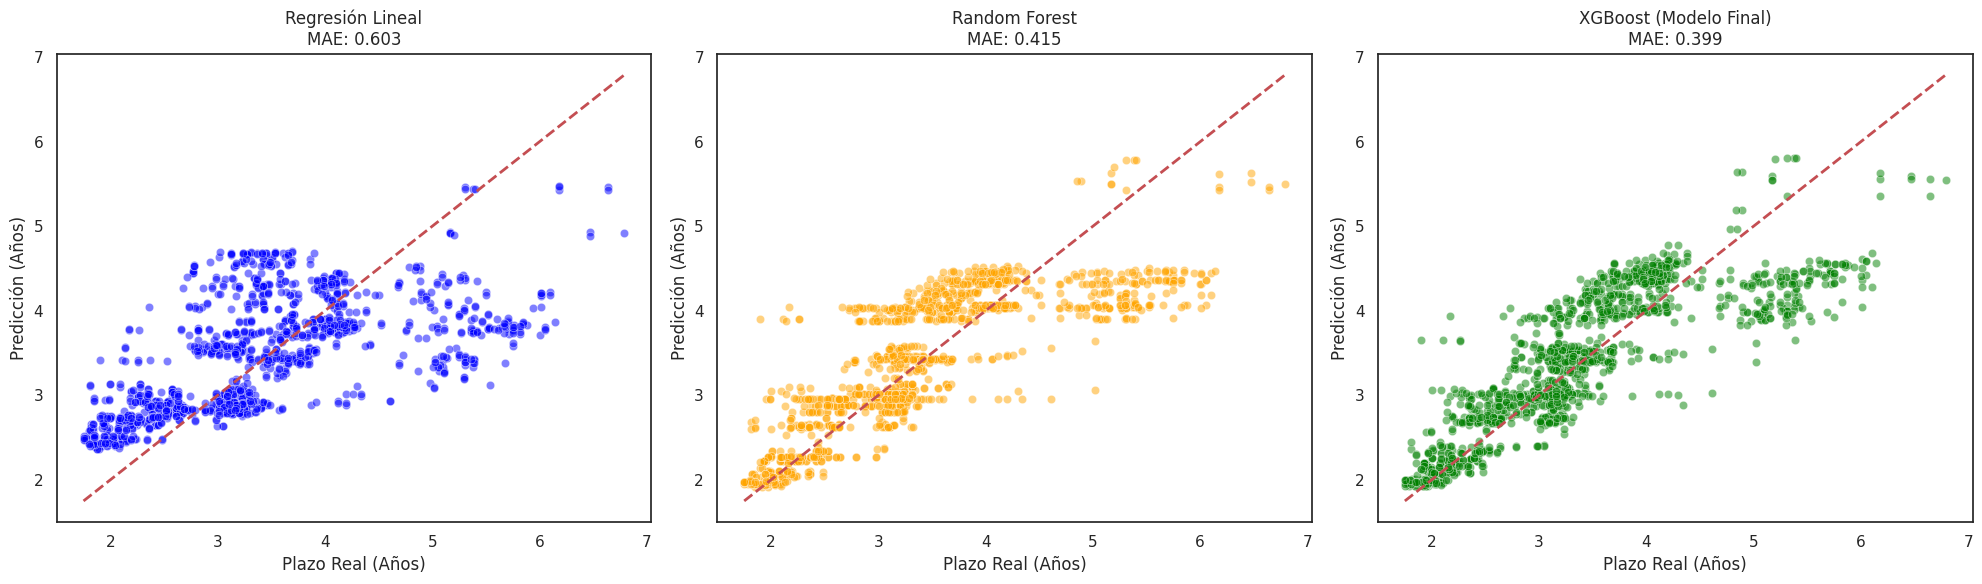

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# 1. Gráfico para Regresión Lineal
sns.scatterplot(x=y_test, y=lr_preds, ax=ax1, alpha=0.5, color='blue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title(f'Regresión Lineal\nMAE: {mean_absolute_error(y_test, lr_preds):.3f}')
ax1.set_xlabel('Plazo Real (Años)')
ax1.set_ylabel('Predicción (Años)')

# 2. Gráfico para Random Forest
sns.scatterplot(x=y_test, y=rf_preds, ax=ax2, alpha=0.5, color='orange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title(f'Random Forest\nMAE: {mean_absolute_error(y_test, rf_preds):.3f}')
ax2.set_xlabel('Plazo Real (Años)')
ax2.set_ylabel('Predicción (Años)')

# 3. Gráfico para XGBoost (El ganador)
sns.scatterplot(x=y_test, y=xgb_preds, ax=ax3, alpha=0.5, color='green')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_title(f'XGBoost (Modelo Final)\nMAE: {mean_absolute_error(y_test, xgb_preds):.3f}')
ax3.set_xlabel('Plazo Real (Años)')
ax3.set_ylabel('Predicción (Años)')

plt.tight_layout()
plt.show()

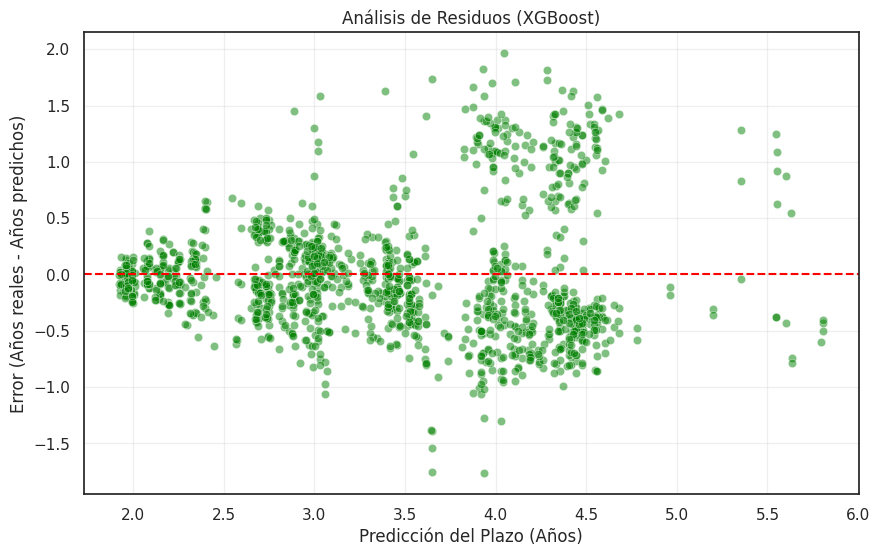

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los residuos del modelo ganador
# Es la diferencia entre lo que debería ser y lo que el modelo ha dicho
residuos_xgb = y_test - xgb_preds

# 2. Generamos el gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=xgb_preds, y=residuos_xgb, color='green', alpha=0.5)

# Añadimos una línea en el 0 (donde el error es inexistente)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Análisis de Residuos (XGBoost)')
plt.xlabel('Predicción del Plazo (Años)')
plt.ylabel('Error (Años reales - Años predichos)')
plt.grid(True, alpha=0.3)
plt.show()

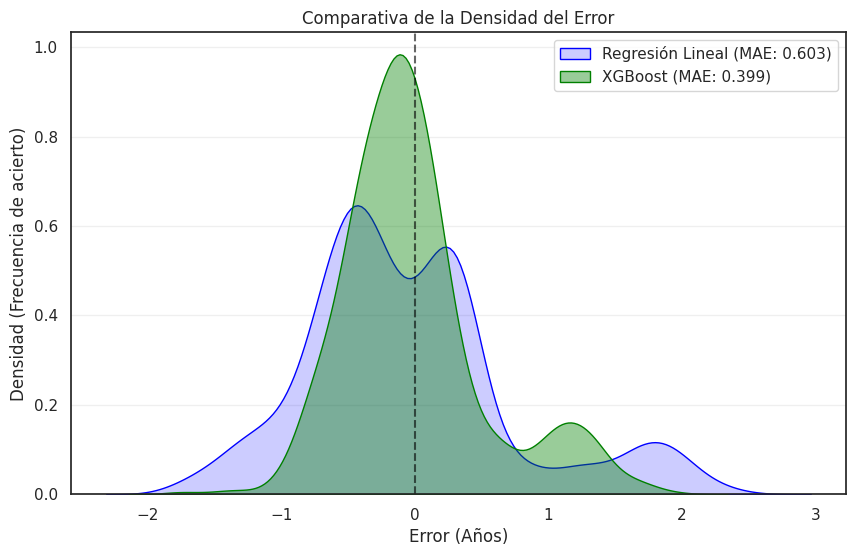

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los residuos de ambos modelos para comparar
residuos_lr = y_test - lr_preds
residuos_xgb = y_test - xgb_preds

# 2. Configuramos el gráfico
plt.figure(figsize=(10, 6))

# Dibujamos la distribución del error de la Regresión Lineal
sns.kdeplot(residuos_lr, label=f'Regresión Lineal (MAE: {mean_absolute_error(y_test, lr_preds):.3f})',
            color='blue', fill=True, alpha=0.2)

# Dibujamos la distribución del error del XGBoost
sns.kdeplot(residuos_xgb, label=f'XGBoost (MAE: {mean_absolute_error(y_test, xgb_preds):.3f})',
            color='green', fill=True, alpha=0.4)

# Formatos finales
plt.axvline(x=0, color='black', linestyle='--', alpha=0.6)
plt.title('Comparativa de la Densidad del Error')
plt.xlabel('Error (Años)')
plt.ylabel('Densidad (Frecuencia de acierto)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

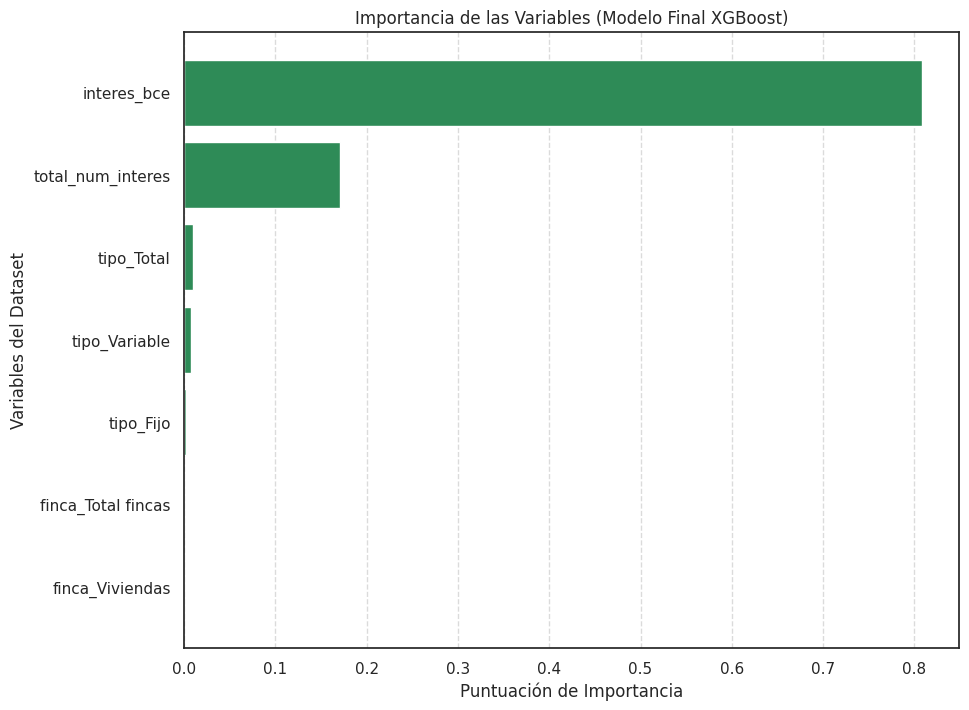

             Variable  Importancia
6         interes_bce     0.808390
0   total_num_interes     0.171234
4          tipo_Total     0.010272
5       tipo_Variable     0.007389
3           tipo_Fijo     0.002327
1  finca_Total fincas     0.000227
2     finca_Viviendas     0.000161


In [132]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraemos las importancias
importancias = xgb_model.feature_importances_
nombres_columnas = X.columns

# 2. Creamos un DataFrame para ordenar los datos
df_importancia = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=True) # Ascending True para que la más importante salga arriba en el gráfico horizontal

# 3. Dibujamos el gráfico
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='seagreen')

plt.title('Importancia de las Variables (Modelo Final XGBoost)')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variables del Dataset')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print(df_importancia.sort_values(by='Importancia', ascending=False))

# Prueba del Modelo

In [133]:
import pandas as pd

# 1. Definimos los datos
datos_dict = {
    'interes_bce': [3.25],
    'total_num_interes': [4.10],
    'tipo_Total': [1],
    'tipo_Variable': [0],
    'tipo_Fijo': [0],
    'finca_Total fincas': [15000],
    'finca_Viviendas': [12000]
}

# 2. Creamos el DataFrame
escenario_df = pd.DataFrame(datos_dict)

# 3. Reordenamos las columnas para que sean IGUALES a las de X. Esto garantiza que el modelo no se queje del orden
escenario_df = escenario_df[X.columns]

# 4. Predecimos
prediccion = xgb_model.predict(escenario_df)

print(f"--- PREDICCIÓN SIN ERRORES ---")
print(f"Resultado: {prediccion[0]:.2f} años")

--- PREDICCIÓN SIN ERRORES ---
Resultado: 4.02 años


In [114]:
import pandas as pd

# 1. Definimos 3 escenarios: Interés Bajo, Medio (el de antes) y Alto
escenarios = [
    {'nombre': 'Escenario Tipos Bajos', 'bce': 1.50, 'banco': 2.50},
    {'nombre': 'Escenario Actual', 'bce': 3.25, 'banco': 4.10},
    {'nombre': 'Escenario Tipos Altos', 'bce': 5.50, 'banco': 6.00}
]

resultados = []

for e in escenarios:
    # Creamos el diccionario manteniendo el resto de variables fijas
    datos_dict = {
        'interes_bce': [e['bce']],
        'total_num_interes': [e['banco']],
        'tipo_Total': [1],
        'tipo_Variable': [0],
        'tipo_Fijo': [0],
        'finca_Total fincas': [15000],
        'finca_Viviendas': [12000]
    }

    df_temp = pd.DataFrame(datos_dict)
    df_temp = df_temp[X.columns] # Reordenar columnas

    pred = xgb_model.predict(df_temp)[0]
    resultados.append({'Escenario': e['nombre'], 'BCE (%)': e['bce'], 'Predicción (Años)': round(pred, 2)})

# Mostrar la tabla comparativa
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

               Escenario  BCE (%)  Predicción (Años)
0  Escenario Tipos Bajos     1.50               2.15
1       Escenario Actual     3.25               4.02
2  Escenario Tipos Altos     5.50               5.43


In [134]:
import joblib

# Guardamos el modelo ganador y las columnas originales para no perder el orden
joblib.dump(xgb_model, 'modelo_hipotecas_xgb.pkl')
joblib.dump(X.columns, 'columnas_modelo.pkl')

['columnas_modelo.pkl']

/tmp/ipykernel_2071/3569135477.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=df_plot, ax=ax1, palette='viridis')
/tmp/ipykernel_2071/3569135477.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R2 Score', data=df_plot, ax=ax2, palette='magma')


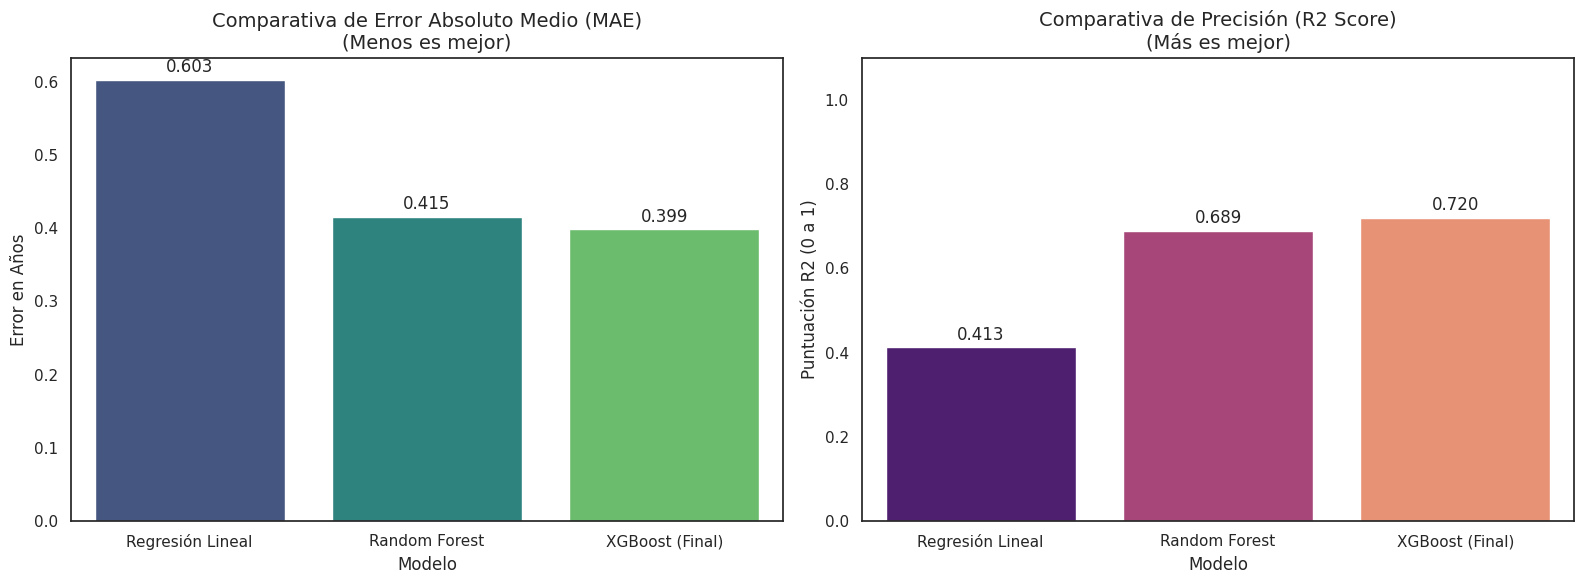

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = resumen_metricas.reset_index().rename(columns={'index': 'Modelo'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: MAE (Cuanto más bajo, mejor)
sns.barplot(x='Modelo', y='MAE', data=df_plot, ax=ax1, palette='viridis')
ax1.set_title('Comparativa de Error Absoluto Medio (MAE)\n(Menos es mejor)', fontsize=14)
ax1.set_ylabel('Error en Años')
# Añadimos los valores encima de las barras
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Gráfico B: R2 Score (Precisión - Cuanto más alto, mejor)
sns.barplot(x='Modelo', y='R2 Score', data=df_plot, ax=ax2, palette='magma')
ax2.set_title('Comparativa de Precisión (R2 Score)\n(Más es mejor)', fontsize=14)
ax2.set_ylabel('Puntuación R2 (0 a 1)')
ax2.set_ylim(0, 1.1)
# Añadimos los valores encima de las barras
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

In [136]:
import joblib
from google.colab import files

# 1. Guardamos el modelo y el orden de las columnas
joblib.dump(xgb_model, 'modelo_final_tfm.pkl')
joblib.dump(X.columns, 'columnas_tfm.pkl')

# 2. Descargamos los archivos
files.download('modelo_final_tfm.pkl')
files.download('columnas_tfm.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>